# C3. 표본 크기와 신뢰구간

| | |
|---|---|
| **트랙** | C 평가 |
| **선수 토픽** | C1, C2 |
| **프로젝트 앵커** | `FACET_BOOST` 스윕 0.945→0.953 · 300→400문항 확장 · `baseline_20260722.lock` |
| **작성일** | 2026-07-30 |
| **최종 검증** | 2026-07-30 |
| **상태** | 검증완료 |

## 한 줄 요약
> 400문항에서 hit@3의 95% 신뢰구간 반폭은 ±0.02가 넘고, `FACET_BOOST`의 +0.008은
> net 3문항이라 어떤 검정을 들이대도 유의해질 수 없는 크기다.

## 0. 준비

필요 패키지는 `numpy`, `matplotlib` 뿐이다(정확 검정의 이항 계수는 표준 라이브러리 `math.comb`로
충분하다). hit@3은 문항별 성패의 평균, 즉 이항 비율이므로 점수·문항 수·win/loss 건수만 있으면
신뢰구간과 검정이 전부 계산된다. §4는 프로젝트 실측치를 그대로 입력으로 쓴다.

In [1]:
# ── 표준 셋업 ────────────────────────────────────────────
from __future__ import annotations

import pathlib
import random
from math import comb

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

ASSETS = pathlib.Path("../assets")
OUT = pathlib.Path("./out"); OUT.mkdir(exist_ok=True)
np.set_printoptions(precision=4, suppress=True)

# 팔레트 (FUNDAMENTAL 시리즈 공용)
C_MAIN, C_SUB, C_GRAY = "#ee4c2c", "#0d9488", "#94a3b8"

_installed = {f.name for f in fm.fontManager.ttflist}
for _f in ("AppleGothic", "Malgun Gothic", "NanumGothic"):
    if _f in _installed:
        mpl.rcParams["font.family"] = _f
        break
mpl.rcParams["axes.unicode_minus"] = False
mpl.rcParams["figure.figsize"] = (7, 4)
mpl.rcParams["figure.dpi"] = 120
mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.alpha"] = 0.25
mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False

print(f"seed={SEED} · font={mpl.rcParams['font.family'][0]}")

seed=42 · font=sans-serif


## 1. 개념

### hit@3은 이항 비율이다

문항 $n$개 각각의 성패가 확률 $p$의 베르누이라면, 관측 점수 $\hat p$의 표준오차는

> **정의**
> $$\mathrm{SE}(\hat p) = \sqrt{\frac{p(1-p)}{n}}, \qquad
> \text{Wilson 95\% 구간} = \frac{\hat p + \frac{z^2}{2n} \pm
> z\sqrt{\frac{\hat p(1-\hat p)}{n} + \frac{z^2}{4n^2}}}{1 + \frac{z^2}{n}}$$
> 교과서의 $\hat p \pm z\,\mathrm{SE}$ (Wald)는 $\hat p$가 1에 가깝거나 $n$이 작으면
> 구간이 $[0,1]$을 벗어나거나 실제보다 좁아진다. Wilson이 그 자리의 표준 대체재다.

$\mathrm{SE}$가 $\sqrt{n}$으로 줄어든다는 것은 **오차를 절반으로 줄이려면 문항을 4배 모아야
한다**는 뜻이다. 300문항을 400으로 늘리는 종류의 확장이 SE를 얼마나 줄이는지는 §3에서 실제
숫자로 확인하는데, 미리 말하면 13%다.

### 같은 셋 위의 두 설정은 독립 표본이 아니다

`FACET_BOOST` 0.03과 0.08은 같은 400문항에서 채점됐다. 이런 쌍대(paired) 비교에서 문항은
넷으로 갈린다. 둘 다 맞힘, 둘 다 틀림, A만 맞힘($c$건), B만 맞힘($b$건). 앞의 두 부류는 두
설정을 구별하는 정보가 전혀 없다. **차이에 대한 정보는 오직 승패가 갈린 $b+c$건에만 있다.**

> **정의**  McNemar 정확 검정. 귀무가설(두 설정 동등) 아래서 갈린 문항의 승패는 공정한
> 동전이다.
> $$b \mid (b+c) \sim \mathrm{Bin}(b+c, \tfrac{1}{2})$$
> 양측 p값은 $2\Pr[X \ge \max(b,c)]$ 로 계산한다.

### CI 겹침으로 판정하지 말 것

> **함정**  "두 설정의 95% CI가 겹치니 차이가 없다"는 추론은 두 방향 모두 틀린다. 겹쳐도
> 쌍대 검정에서는 유의할 수 있고(공유한 문항의 난이도 변동이 두 CI를 같이 흔들기 때문),
> CI 겹침 판정 자체가 5%보다 훨씬 보수적인 기준이기 때문이다. 개별 CI는 각 점수의 정밀도
> 표시로만 쓰고, 차이의 판정은 처음부터 $b, c$로 해야 한다.

### 오차를 줄이는 손잡이는 세 개다

| 손잡이 | 효과 | 비용 |
|---|---|---|
| 문항 수 $n$ | $\mathrm{SE} \propto 1/\sqrt{n}$ | 라벨링 (C5의 오류율 관리 포함) |
| 쌍대 설계 | 갈린 문항만 남겨 분산 축소 | 같은 셋 재사용 → 다중비교 위험(§4-4) |
| 반복 스윕 축소 | 최댓값 선택의 낙관 편향 제거 | 탐색 범위 축소 |

첫 손잡이는 비싸고 둘째는 공짜처럼 보이지만, 둘째와 셋째는 서로 상충한다. 같은 셋을 여러 번
쓸수록 쌍대 설계의 이득이 선택 편향으로 되돌아온다.

## 2. 최소 구현

Wilson 구간과 McNemar 정확 검정은 각각 함수 하나다. 예시는 §1의 함정을 그대로 재연한다.
n=200에서 0.90과 0.93의 CI는 넉넉히 겹치지만, 갈린 문항이 8:2였다면 이야기가 달라진다.

In [2]:
Z95 = 1.959964


def wilson_ci(k: int, n: int, z: float = Z95) -> tuple[float, float]:
    """성공 k / 시행 n의 Wilson 95% 신뢰구간."""
    p = k / n
    denom = 1 + z * z / n
    center = (p + z * z / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / denom
    return center - half, center + half


def mcnemar_exact(b: int, c: int) -> float:
    """쌍대 비교의 양측 정확 p값. b, c는 승패가 갈린 문항 수."""
    n = b + c
    if n == 0:
        return 1.0
    tail = sum(comb(n, x) for x in range(max(b, c), n + 1)) / 2 ** n
    return min(1.0, 2 * tail)


ka, kb, n = 180, 186, 200                     # 0.90 vs 0.93, 같은 200문항
print(f"A: {ka / n:.3f} CI [{wilson_ci(ka, n)[0]:.4f}, {wilson_ci(ka, n)[1]:.4f}]")
print(f"B: {kb / n:.3f} CI [{wilson_ci(kb, n)[0]:.4f}, {wilson_ci(kb, n)[1]:.4f}]")
print(f"겹침 여부: {'겹침' if wilson_ci(kb, n)[0] < wilson_ci(ka, n)[1] else '분리'}")
print(f"쌍대 검정 (b=8, c=2): p = {mcnemar_exact(8, 2):.4f}")

A: 0.900 CI [0.8506, 0.9343]
B: 0.930 CI [0.8859, 0.9578]
겹침 여부: 겹침
쌍대 검정 (b=8, c=2): p = 0.1094


CI는 겹치는데 쌍대 p값은 0.11로, 겹침 판정보다 훨씬 유의 쪽에 가깝다. 어느 쪽으로 판정하느냐가
채택·기각을 가를 수 있는 폭이며, 판정 도구는 처음부터 $b, c$ 기반이어야 한다는 §1의 주장이
이 네 줄에 들어 있다.

## 3. 프로젝트 앵커

`FACET_BOOST` 스윕에서 0.03은 0.945, 0.08은 0.953을 기록했다(400문항, `baseline_20260722.lock`).
성공 건수로 바꾸면 378건과 381.2건, 즉 0.953은 381/400 = 0.9525의 셋째 자리 반올림으로 추정되고
**net 차이는 3문항**이다.

> **프로젝트**  이 +0.008이 실개선인지가 C1 §4-3 이후 계속 미뤄 온 질문이다. C1의 재추출
> 실험에서 400문항 hit@3의 95% 폭이 0.06 수준이었으니 답은 짐작되지만, 재추출은 독립 표본
> 가정이라 쌍대 상황에는 과한 비관이다. 정확한 판정은 §4-2에서 net 3문항을 직접 검정한다.

> **함정**  락에는 점수만 남고 win/loss 분해($b$, $c$)가 없다. §4-2에서 보듯 같은 net +3이라도
> $b=3, c=0$과 $b=13, c=10$은 discordant 비율 추정을 완전히 다르게 만들고, 그 비율이 §4-3의
> 표본 설계 전체를 좌우한다. **점수 차이만 기록하는 락은 판정에 필요한 정보의 절반을 버리고
> 있다.**

300문항 셋을 400으로 늘린 이력도 이 노트북의 관심사다. p=0.945 기준 SE는 0.0132에서 0.0114로
줄었다. 문항을 33% 늘려 얻은 것이 오차 13% 감소이며, 이 교환비가 타당했는지는 §4-5에서 라벨
정제라는 대안과 나란히 놓고 계산한다.

## 4. 숫자 검증

### 4-1. 실측치에 구간을 붙이면

프로젝트에 기록된 네 값에 Wilson 구간을 붙인다. 그룹별 문항 수는 기록에 없으므로, 기록된
비율을 소수 셋째 자리 반올림으로 재현하는 분모를 C2의 가정 배분 근방에서 역산했다
(0.889 → 32/36, 0.984 → 62/63). 비교를 위해 Wald 구간도 함께 놓는다.

In [3]:
ROWS = [
    ("전체 (0.945)", 378, 400),
    ("FACET 0.08 (0.953)", 381, 400),
    ("착오송금 (역산 n)", 32, 36),          # 32/36 = 0.8889 → 기록값 0.889
    ("은닉 (역산 n)", 62, 63),              # 62/63 = 0.9841 → 기록값 0.984
]

print(f"{'row':<20}{'p':>7}{'Wald':>19}{'Wilson':>19}")
print("-" * 65)
for name, k, n in ROWS:
    p = k / n
    se = np.sqrt(p * (1 - p) / n)
    wa = (p - Z95 * se, p + Z95 * se)
    wi = wilson_ci(k, n)
    print(f"{name:<20}{p:>7.4f}"
          f"{wa[0]:>9.4f}~{wa[1]:<9.4f}{wi[0]:>9.4f}~{wi[1]:<9.4f}")

print(f"\n전체 400문항의 Wilson 반폭 ≈ ±{(wilson_ci(378, 400)[1] - wilson_ci(378, 400)[0]) / 2:.4f}")

row                       p               Wald             Wilson
-----------------------------------------------------------------
전체 (0.945)           0.9450   0.9227~0.9673      0.9181~0.9634   
FACET 0.08 (0.953)   0.9525   0.9317~0.9733      0.9270~0.9694   
착오송금 (역산 n)          0.8889   0.7862~0.9915      0.7469~0.9559   
은닉 (역산 n)            0.9841   0.9533~1.0150      0.9154~0.9972   

전체 400문항의 Wilson 반폭 ≈ ±0.0226


세 가지가 보인다. 첫째, 전체 점수의 반폭이 ±0.023으로 `FACET_BOOST` 차이 +0.008의 세 배다.
둘째, 은닉 행에서 Wald 상한은 1.015로 **확률이 1을 넘는다.** 소표본·경계 근처에서 Wald를 쓰면
안 되는 이유가 표 안에 그대로 있다. 셋째, 착오송금의 구간은 [0.75, 0.96]으로, C2에서 "약한
그룹"이라 불렀던 0.889가 사실은 서른몇 문항 위의 점 추정일 뿐이라는 것도 드러난다. 그룹별 진단
자체가 표본 부족에 시달리고 있다.

다만 §1의 함정대로, 0.945와 0.953의 CI가 겹친다는 사실은 판정이 아니다. 판정은 다음이다.

### 4-2. net 3문항은 유의해질 수 없다

락에는 net +3만 남아 있고 $b, c$ 분해가 없으므로, **가능한 모든 분해**를 검정한다. 아울러
$c=0$(순수 개선)일 때 net이 몇 문항부터 유의해지는지도 함께 잰다.

In [4]:
print("net +3의 가능한 분해와 정확 p값")
print(f"{'b':>4}{'c':>4}{'discordant':>12}{'p':>9}")
print("-" * 29)
for b, c in ((3, 0), (5, 2), (8, 5), (13, 10), (23, 20)):
    print(f"{b:>4}{c:>4}{b + c:>12}{mcnemar_exact(b, c):>9.4f}")

print("\nc=0(역전 없는 순수 개선)에서 net별 p값")
print(f"{'net':>4}{'p':>9}{'판정':>7}")
print("-" * 20)
for b in range(3, 8):
    p = mcnemar_exact(b, 0)
    print(f"{b:>4}{p:>9.4f}{'유의' if p < 0.05 else '-':>7}")

net +3의 가능한 분해와 정확 p값
   b   c  discordant        p
-----------------------------
   3   0           3   0.2500
   5   2           7   0.4531
   8   5          13   0.5811
  13  10          23   0.6776
  23  20          43   0.7608

c=0(역전 없는 순수 개선)에서 net별 p값
 net        p     판정
--------------------
   3   0.2500      -
   4   0.1250      -
   5   0.0625      -
   6   0.0312     유의
   7   0.0156     유의


net +3은 가장 유리한 분해($b=3, c=0$)에서도 p=0.25이고, discordant가 늘수록 p는 0.76까지
**커진다.** 즉 win/loss 로그를 확인할 필요조차 없이, 이 락의 +0.008은 어떤 경우에도 유의해질
수 없다. 0.953을 채택한 결정이 틀렸다는 뜻이 아니라, **그 결정이 통계적 근거 위에 있지 않았다는
사실이 확정**된다는 뜻이다.

기준선도 나온다. 역전이 하나도 없어도 net +6(= +0.015)은 되어야 p가 0.05 아래로 내려간다.
400문항 셋에서 그보다 작은 차이는 전부 동률로 취급하는 것이 정직한 규칙이다.

### 4-3. 이 셋이 잡아낼 수 있는 차이의 크기

거꾸로 물을 수도 있다. 80% 확률로 잡아내려면(검정력 0.8) 차이가 얼마나 커야 하는가. McNemar의
정규 근사에서 검출 가능한 최소 차이는 $\delta_{\min} \approx (z_{\alpha/2} + z_{\beta})
\sqrt{p_d / n}$ 로 떨어진다($p_d$는 discordant 비율, $\delta^2 \ll p_d$ 가정). 이 곡선 위에
프로젝트의 위치를 놓는다.

/tmp/ipykernel_6408/582288792.py:34: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6408/582288792.py:34: UserWarning: Glyph 54637 (\N{HANGUL SYLLABLE HANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6408/582288792.py:34: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6408/582288792.py:34: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6408/582288792.py:34: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6408/582288792.py:34: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6408/582288792.py:34: UserWarning: Glyph 45733 (\N{HANGUL SYLLABLE NEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout

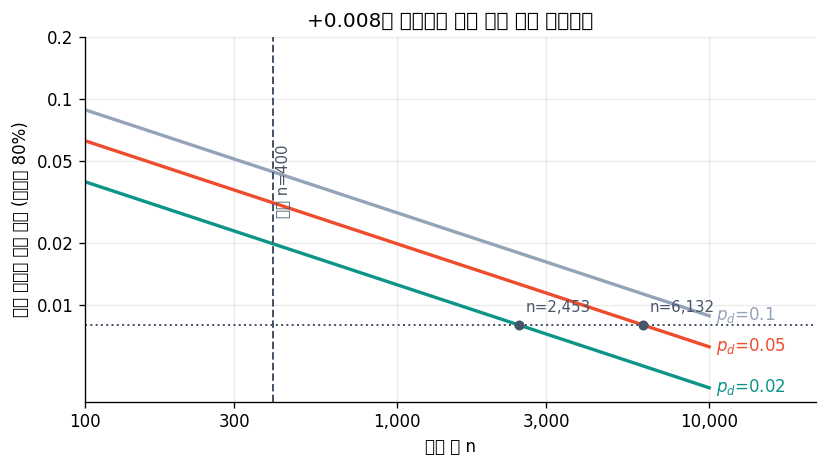

n=400에서의 검출 한계: p_d=0.02 → 0.0198 · p_d=0.05 → 0.0313


In [5]:
Z_POWER = Z95 + 0.841621                    # z_0.025 + z_0.80
ns = np.logspace(2, 4, 200)                  # 100 ~ 10,000 문항


def delta_min(n: np.ndarray, p_d: float) -> np.ndarray:
    """검정력 80%로 검출 가능한 최소 net 차이(정규 근사)."""
    return Z_POWER * np.sqrt(p_d / n)


fig, ax = plt.subplots()
for p_d, color in ((0.02, C_SUB), (0.05, C_MAIN), (0.10, C_GRAY)):
    ax.plot(ns, delta_min(ns, p_d), color=color, lw=2.0)
    ax.text(ns[-1] * 1.05, delta_min(ns[-1], p_d), f"$p_d$={p_d}",
            color=color, va="center", fontsize=10)

ax.axhline(0.008, color="#475569", ls=":", lw=1.2)
ax.axvline(400, color="#475569", ls="--", lw=1.2)
for p_d in (0.02, 0.05):
    n_need = (Z_POWER / 0.008) ** 2 * p_d
    ax.plot(n_need, 0.008, "o", color="#475569", ms=5)
    ax.annotate(f"n={n_need:,.0f}", (n_need, 0.008), textcoords="offset points",
                xytext=(4, 8), fontsize=9, color="#475569")

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(100, 22000)
ax.set_xticks([100, 300, 1000, 3000, 10000],
              ["100", "300", "1,000", "3,000", "10,000"])
ax.set_yticks([0.01, 0.02, 0.05, 0.1, 0.2], ["0.01", "0.02", "0.05", "0.1", "0.2"])
ax.minorticks_off()
ax.set_xlabel("문항 수 n")
ax.set_ylabel("검출 가능한 최소 차이 (검정력 80%)")
ax.set_title("+0.008을 잡으려면 문항 수천 개가 필요하다")
ax.text(405, 0.06, "현재 n=400", color="#475569", fontsize=9, rotation=90, va="top")
plt.tight_layout()
plt.show()

print(f"n=400에서의 검출 한계: p_d=0.02 → {delta_min(np.array([400]), 0.02)[0]:.4f}"
      f" · p_d=0.05 → {delta_min(np.array([400]), 0.05)[0]:.4f}")

400문항의 검출 한계는 discordant 비율에 따라 0.020~0.031이다. hit@3 기준 **2~3%p보다 작은
개선은 이 셋의 해상도 바깥**에 있고, +0.008을 80% 검정력으로 판정하려면 2,500~6,100문항이
필요하다. 300→400 확장이 검출 한계를 거의 움직이지 못한 이유도 곡선의 기울기($n^{-1/2}$)에서
바로 읽힌다.

이 곡선은 판정 도구라기보다 **실험 설계 도구**다. 다음 개선안의 기대 효과가 +0.01이라면 셋을
늘리기 전까지 그 실험은 결론이 나지 않을 실험이고, +0.05라면 지금 셋으로 충분하다.

### 4-4. 같은 셋에서 고른 최고점은 부풀어 있다

스윕은 여러 설정 중 최고를 고르는 절차다. 진짜 차이가 전부 0이어도 최고점은 잡음의 최댓값만큼
기준선 위에 뜬다. 문항별 성패를 고정한 기준 설정에서, 각 설정이 문항의 5%만 무작위로 다시
뽑는(성능은 동일한) 스윕을 돌려 **최고 설정의 관측 이득**을 잰다.

In [6]:
def sweep_bias(k_settings: int, n: int = 400, p: float = 0.945,
               p_d: float = 0.05, reps: int = 1500) -> float:
    """성능이 전부 같은 k개 설정을 스윕했을 때 최고점의 기대 이득."""
    rng = np.random.default_rng(SEED)
    base = rng.random((reps, n)) < p
    flip = rng.random((reps, k_settings, n)) < p_d
    redraw = rng.random((reps, k_settings, n)) < p
    trial = np.where(flip, redraw, base[:, None, :])
    gains = trial.mean(axis=2) - base.mean(axis=1, keepdims=True)
    return float(gains.max(axis=1).mean())


print(f"{'k settings':>11}{'E[best gain]':>14}")
print("-" * 25)
for k in (1, 3, 5, 10, 20):
    print(f"{k:>11}{sweep_bias(k):>+14.4f}")

 k settings  E[best gain]
-------------------------
          1       -0.0001
          3       +0.0028
          5       +0.0040
         10       +0.0053
         20       +0.0066


설정 5개짜리 스윕이면 **아무 개선이 없어도** 최고점이 +0.004를 보이고, 20개면 +0.007에
이른다. `FACET_BOOST`의 +0.008은 스윕 그리드가 10~20개였다면 상당 부분이 이 선택 편향만으로
설명되는 크기다. 락에 그리드 크기가 남아 있지 않으므로 단정은 못 하지만, 방향은 분명하다.
**같은 셋에서 스윕으로 고른 값을 같은 셋의 점수로 보고하면, 그 점수는 정의상 낙관적이다.**
스윕용과 확정용 셋을 분리하는 표준 처방이 여기서 나온다.

### 4-5. 문항을 늘릴 것인가, 라벨을 고칠 것인가

C5가 넘긴 투자 질문을 같은 단위로 놓는다. 이미 잡아낸 gt 8건과 비슷한 규모의 오류가 아직
남아 있다는 보수적 가정 아래, 현재 상태(n=400, 잔존 오류율 e=8/52)에서 출발해,
문항 4배 확장과 오류율 절반 정제가 각각 무엇을 얼마나 줄이는지 비교한다. 관측 점수의 오차는
$\sqrt{n}$으로 줄어드는 표본 오차와, $n$과 무관한 라벨 편향 $e(s - q)$의 합이다(C5 §4-1).

In [7]:
s_true, q_chance, p_obs = 0.85, 0.05, 0.945
plans = [
    ("현재", 400, 8 / 52),
    ("문항 4배", 1600, 8 / 52),
    ("오류 절반", 400, 4 / 52),
    ("둘 다", 1600, 4 / 52),
]

print(f"{'plan':<10}{'n':>6}{'e':>8}{'표본SE':>9}{'라벨편향':>10}{'합계':>8}")
print("-" * 51)
for name, n, e in plans:
    se = np.sqrt(p_obs * (1 - p_obs) / n)
    bias = e * (s_true - q_chance)
    print(f"{name:<10}{n:>6d}{e:>8.4f}{se:>9.4f}{bias:>10.4f}{se + bias:>8.4f}")

plan           n       e     표본SE      라벨편향      합계
---------------------------------------------------
현재           400  0.1538   0.0114    0.1231  0.1345
문항 4배       1600  0.1538   0.0057    0.1231  0.1288
오류 절반        400  0.0769   0.0114    0.0615  0.0729
둘 다         1600  0.0769   0.0057    0.0615  0.0672


라벨 편향이 표본 오차의 **10배**다. 문항을 4배로 늘리는 큰 투자가 합계 오차를 0.006 줄이는
동안, 라벨 오류를 절반으로 정제하면 0.062가 줄어든다. 지금 상태에서 다음 한 시간을 쓸 곳은
라벨링 확장이 아니라 기존 52건의 재검토라는 답이 숫자로 나온다. 단, 이 비교는 절대 점수의
오차 기준이다. 쌍대 비교에서는 오라벨 문항이 양쪽 설정을 함께 틀리게 만들어 concordant로
빠지므로 영향이 이보다 작을 수 있는데, 그 크기는 재보지 않았다(§5).

§4를 한 줄로 줄이면 이렇다. **평가셋에는 해상도가 있고, 해상도 미만의 차이를 읽는 것은
측정이 아니라 점술이다.** 400문항의 해상도는 2~3%p이고, 그 아래의 +0.008을 근거로 락을
바꾸는 일은 잡음에 파라미터를 맞추는 일이었다.

이로써 0단계가 닫힌다. 숫자 하나를 읽으려면 다섯 겹을 통과해야 한다. 그 숫자가 세는 것이
무엇인지(C1), 질의가 어떻게 만들어졌는지(C4), gold를 누가 어떤 규칙으로 정했는지(C5), 그룹을
어떤 가중치로 합쳤는지(C2), 그리고 그 크기가 셋의 해상도 위에 있는지(C3). 이후 트랙에서
등장하는 모든 실험 수치는 이 다섯 질문을 통과한 뒤에만 결론이 된다.

## 5. 남은 질문

- `FACET_BOOST` 스윕의 그리드 크기를 확인해야 한다. §4-4의 편향 추정은 k에 직접 걸리며,
  k를 알면 +0.008 중 선택 편향 몫의 기대값을 바로 뺄 수 있다.
- win/loss 문항 로그가 남아 있는가? $b, c$ 분해는 유의성 판정(§4-2)에는 이미 불필요하지만,
  discordant 비율 $p_d$의 실측치가 있어야 §4-3 곡선에서 우리 위치가 확정된다.
- 락 채택 규칙을 명문화할 필요가 있다. §4-2 기준으로 "400문항 셋에서 net +6 미만은 동률"이
  자연스러운 출발점이고, 동률일 때 무엇을 우선할지(단순성, 지연시간)는 별도 결정이다.
- 스윕용 셋과 확정용 셋의 분리 비용은 얼마인가? 400을 300+100으로 쪼개면 확정 셋의 해상도가
  다시 나빠지므로, 분리가 답인지 셋 확장이 답인지는 §4-3 곡선 위에서 계산할 문제다.
- §4-3의 근사식은 $\delta^2 \ll p_d$ 가정 위의 일차 근사다. 경계 근처($p_d$가 아주 작을 때)
  정확 검정력 시뮬레이션으로 곡선을 재확인하지 않았다.
- 이항 가정 자체도 점검 대상이다. 문항이 업무 구분으로 묶여 있고 구분 안 난이도가 상관되면
  유효 표본 수는 400보다 작다. C2의 배분 확인과 묶어 cluster bootstrap으로 재볼 문제다.
- 쌍대 비교에서 라벨 오류의 영향(§4-5 말미)은 정량화하지 않았다. 오라벨 문항의 discordant
  기여율을 모델에 넣으면 C5 §4-1의 격차 압축이 검정력에 주는 손실로 번역될 것이다.

## 참고

- Brown, Cai & DasGupta (2001), *Interval Estimation for a Binomial Proportion* —
  Wald 대신 Wilson을 권하는 표준 논거
- McNemar (1947), *Note on the Sampling Error of the Difference Between Correlated
  Proportions or Percentages*
- Smucker, Allan & Carterette (2007), *A Comparison of Statistical Significance Tests
  for Information Retrieval Evaluation*
- Card et al. (2020), *With Little Power Comes Great Responsibility* — NLP 평가의 검정력 부족
- Gelman & Loken (2014), *The Statistical Crisis in Science* — 다중비교와 garden of
  forking paths
- 프로젝트: `baseline_20260722.lock`, `eval.py`, 300→400 확장 이력